In [1]:
import time
import sys
import os
import argparse
import torch.nn.functional as F
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import jammy_flows
from scipy.stats import norm
from helper_NF import train_model, get_normalized_data, plot_pdf, plot_loss, test_model, evaluate_uncertainty     

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!


### See helper_NF for definitions of train model, get normalized data, plot pdf, plot loss and test model. OBS excuse the chaos 
(didn't have time to use everything and the helper_NF file is sadly a little messy) 

### Data preprocessing
Same as previous assigments, load the data, define hyperparameters, normalize, create tensor, split data and create dataloaders. 

In [2]:
DATA_PATH = "./data_galah"
fp64_on_cpu = False

# Hyperparameters
learning_rate = 1e-4
batch_size = 32

num_epochs = 100
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7 # Fraction of the data used for training
val_fraction = 0.15 # Fraction of the data used for validation


In [3]:
# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)


# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


### Model definition

In [4]:

# Define the CNN encoder model. The output of the model is the input to the normalizing flow.
# The latent dimension is the number of parameters in the normalizing flow.
class TinyCNNEncoder(nn.Module):
    def __init__(self, latent_dimension):
        super(TinyCNNEncoder, self).__init__()

        self.model = nn.Sequential(
        nn.Linear(spectra_length, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, latent_dimension),
)

    def forward(self, x):
        x = self.model(x)
        return x


### Loss function definition

In [5]:
def nf_loss(inputs, batch_labels, model):
    """
    Computes the loss for a normalizing flow model.

    Parameters
    ----------
    inputs : torch.Tensor
        The input data to the model.
    batch_labels : torch.Tensor
        The labels corresponding to the input data.
    model : torch.nn.Module
        The normalizing flow model used for evaluation.
    Returns
    -------
    torch.Tensor
        The computed loss value.
    """
    log_pdfs = model.log_pdf_evaluation(batch_labels, inputs) # get the probability of the labels given the input data
    loss = -log_pdfs.mean() # take the negative mean of the log probabilities
    return loss


### Defining the normalizing flow model 


In [6]:

# Defining the normalizng flow model is a bit more involved and requires knowledge of the jammy_flows library.
# Therefore, we provide the relevant code here.
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a CNN encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        """
        Initializes the normalizing flow model.

        Parameters
        ----------
        encoder : callable
            A function or callable object that returns an encoder model. The encoder model
            should take the number of flow parameters as input and output the latent dimension.
        nf_type : str, optional
            The type of normalizing flow to use. Options are "diagonal_gaussian", "full_gaussian",
            and "full_flow". Default is "diagonal_gaussian".
        Raises
        ------
        Exception
            If an unknown `nf_type` is provided.
        Notes
        -----
        This method sets up a 3-dimensional probability density function (PDF) over Euclidean space (e3)
        using the specified normalizing flow type. The flow structure and options are configured based on
        the provided `nf_type`. The PDF is created using the `jammy_flows` library, and the number of flow
        parameters is determined and printed. The encoder is initialized with the number of flow parameters.
        """

        super().__init__()

        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to 128
        self.encoder = encoder(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        """
        Evaluate the log probability density function (PDF) for the given target labels and input data.

        The normalizing flow parameters are predicted by the encoder network based on the input data.
        Then, the log PDF is evaluated at the position of the label.

        Parameters:
        -----------
        target_labels : torch.Tensor
            The target labels for which the log PDF is to be evaluated.
        input_data : torch.Tensor
            The input data to be encoded and used for evaluating the log PDF.
        Returns:
        --------
        log_pdf : torch.Tensor
            The evaluated log PDF for the given target labels and input data.
        """
        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
            # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
            if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                target_labels = target_labels.cpu().to(torch.float64)
            else:
                latent_intermediate = latent_intermediate.float()
                target_labels = target_labels.float()

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        """
        Sample new points from the PDF given input data.

        Parameters
        ----------
        flow_params : tensor
            Parameters for the normalizing flow, must be of shape (B, L) where B is the batch size and L is the latent dimension.
        samplesize_per_batchitem : int, optional
            Number of samples to draw per batch item. Defaults to 1000.


        Returns
        -------
        tensor
            A tensor of shape (B, S, D) where B is the batch dimension, S is the number of samples, 
            and D is the dimension of the target space for the samples.
        """
        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
            # convert to double
            if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                flow_params = flow_params.cpu().to(torch.float64)
            else:
                flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
            batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):
        """
        Perform a forward pass through the model, predicting the mean and standard deviation of the samples.

        Normalizing flows do not directly predict the target labels. Instead, they predict the parameters of the flow that
        transforms the base distribution to the target distribution. Often, we still want to predict the target labels.
        Then, we can sample from the distribution and form the mean of the samples and their standard deviations.
        This is what this function does.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor.
        Returns
        -------
        torch.Tensor
            A tensor of size (B, D*2) where the first half (size D) are the means, 
            the second half (another D) are the standard deviations.
        """
        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function) 
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """
        # pick out one input from batch
        input_bitem = input_data[batch_index:batch_index+1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(3, 1)
        for dim_ind in range(3):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                true_value = truth[dim_ind].cpu().item()
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)


In [7]:
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("-normalizing_flow_type", default="diagonal_gaussian",
                        choices=["diagonal_gaussian", "full_gaussian", "full_flow"])
    args, _ = parser.parse_known_args()
    print("Using normalizing flow type ", args.normalizing_flow_type)

    model = CombinedModel(TinyCNNEncoder, nf_type=args.normalizing_flow_type)

    # Detect and use Apple Silicon GPU (MPS) if available
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    if args.normalizing_flow_type == "full_flow" and device.type == "mps":
        # MPS does not support double precision, therefore we need to run the flow on the CPU
        fp64_on_cpu = True
    print(f"Using device: {device}, performing fp64 on CPU: {fp64_on_cpu}")
    model.to(device)

Using normalizing flow type  diagonal_gaussian
sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  diagonal
The normalizing flow has  6  parameters...
Using device: mps, performing fp64 on CPU: False


In [10]:
def run_experiment(nf_type, train_loader, val_loader, test_loader, encoder, device):
    global fp64_on_cpu

    print("\n==============================")
    print("Running:", nf_type)
    print("==============================")

    # full flow and full gaussian seemed to need lower lr
    lr = {
        "diagonal_gaussian": 1e-4,
        "full_gaussian": 1e-5,
        "full_flow": 1e-5,
    }[nf_type]


    model = CombinedModel(encoder, nf_type=nf_type)

    #call on train 
    train_losses, val_losses = train_model(
        model,
        train_loader,
        val_loader,
        device,
        epochs=num_epochs,
        lr=lr,
        patience=patience,
    )

    #we test
    test_nll = test_model(model, test_loader, device)
    # eval uncertainties
    means, stds, targets = evaluate_uncertainty(model, test_loader, device)    

    #plot the pdf and save them in files 
    plot_pdf(model, test_loader, device, filename=f"pdf_{nf_type}.png")
    #plot the losses
    plot_loss(train_losses, val_losses, title=f"Loss curve - {nf_type}")

    #scatterplot to get overview of the means
    plt.scatter(means[:,0], targets[:,0], alpha=0.5)
    plt.xlabel("Predicted mean")
    plt.ylabel("True value")
    plt.title("Predicted vs True")
    plt.grid()
    plt.show()

    return model, train_losses, val_losses, test_nll


Running: diagonal_gaussian
lr=0.0001, fp64_on_cpu=False
sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  diagonal
The normalizing flow has  6  parameters...
Epoch 1/100 | Train NLL: 1.4303 | Val NLL: 0.2318
Epoch 2/100 | Train NLL: 0.5007 | Val NLL: -0.2868
Epoch 3/100 | Train NLL: 0.2073 | Val NLL: -0.6190
Epoch 4/100 | Train NLL: -0.0557 | Val NLL: -0.8593
Epoch 5/100 | Train NLL: -0.2598 | Val NLL: -0.8677
Epoch 6/100 | Train NLL: -0.3935 | Val NLL: -0.8368
Epoch 7/100 | Train NLL: -0.5509 | Val NLL: -1.4526
Epoch 8/100 | Train NLL: -0.6531 | Val NLL: -1.4414
Epoch 9/100 | Train NLL: -0.7901 | Val NLL: -1.5072
Epoch 10/100 | Train NLL: -0.8320 | Val NLL: -1.7714
Epoch 11/100 | Train NLL: -0.9601 | Val NLL: -1.7828
Epoch 12/100 | Train NLL: -0.9493 | Val NLL: -2.1484
Epoch 13/100 | Train NLL: -1.0321 | Val NLL: -1.9936
Epoch 14/100 | Train NLL: -1.1131 | Val NLL: -1.5735
Epoch 15/100 | Train NLL: -1.0954 | Val NLL: -1.9274
Epoch 16/100 | T

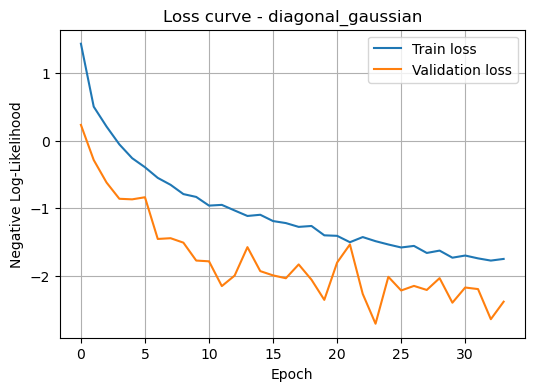

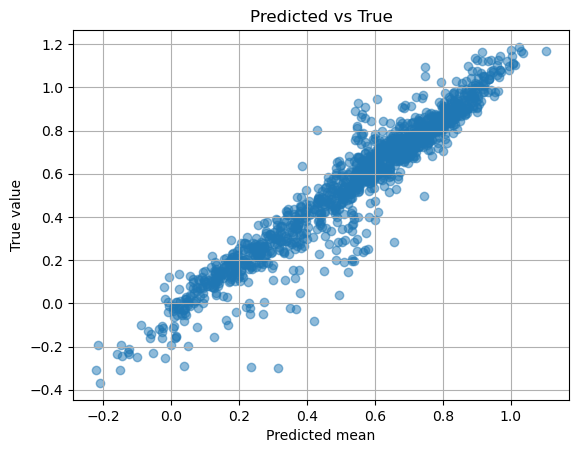


Running: full_gaussian
lr=1e-05, fp64_on_cpu=False
sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  full
The normalizing flow has  9  parameters...
Epoch 1/100 | Train NLL: 2.6467 | Val NLL: 1.7737
Epoch 2/100 | Train NLL: 2.5685 | Val NLL: 1.4711
Epoch 3/100 | Train NLL: 1.8893 | Val NLL: 1.2913
Epoch 4/100 | Train NLL: 1.9793 | Val NLL: 1.1822
Epoch 5/100 | Train NLL: 1.5515 | Val NLL: 0.9662
Epoch 6/100 | Train NLL: 1.4480 | Val NLL: 0.8495
Epoch 7/100 | Train NLL: 1.2477 | Val NLL: 0.7089
Epoch 8/100 | Train NLL: 1.1278 | Val NLL: 0.5492
Epoch 9/100 | Train NLL: 1.0176 | Val NLL: 0.4338
Epoch 10/100 | Train NLL: 0.9193 | Val NLL: 0.3579
Epoch 11/100 | Train NLL: 0.8678 | Val NLL: 0.2717
Epoch 12/100 | Train NLL: 0.7943 | Val NLL: 0.1856
Epoch 13/100 | Train NLL: 0.7139 | Val NLL: 0.1477
Epoch 14/100 | Train NLL: 0.6742 | Val NLL: 0.0641
Epoch 15/100 | Train NLL: 0.6080 | Val NLL: -0.0052
Epoch 16/100 | Train NLL: 0.5661 | Val NLL: -0.001

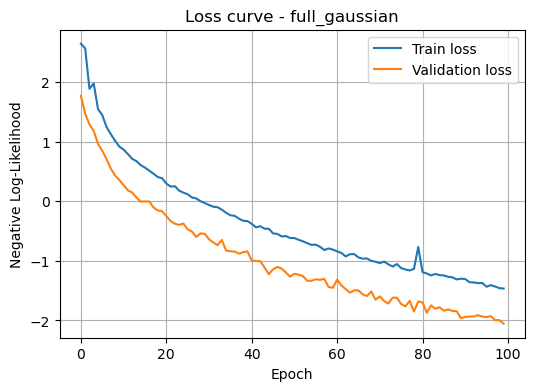

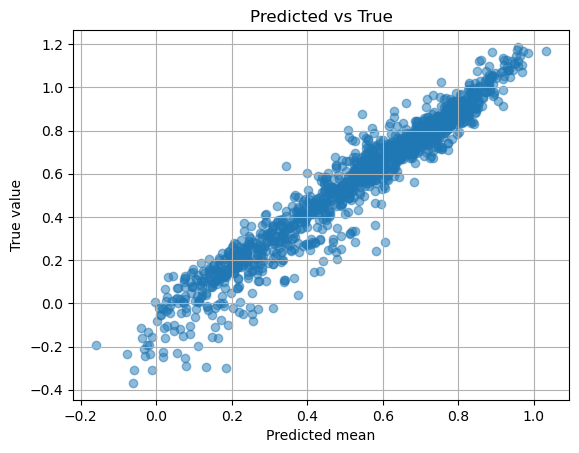


Running: full_flow
lr=1e-05, fp64_on_cpu=True
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g)

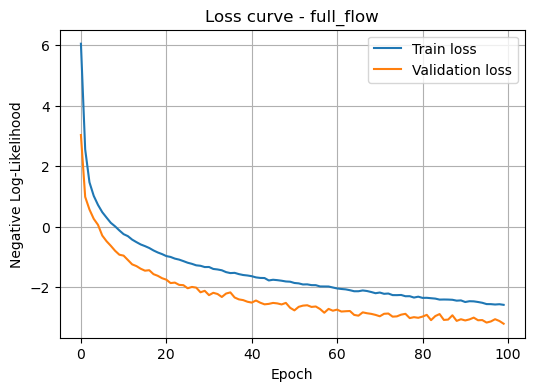

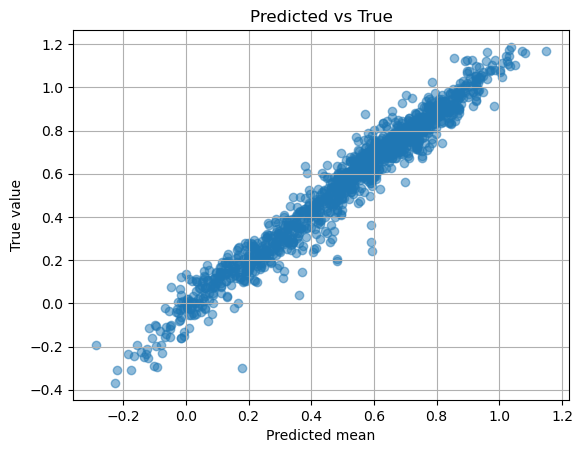

In [9]:
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

encoder = TinyCNNEncoder  

models = {}

for nf_type in ["diagonal_gaussian", "full_gaussian", "full_flow"]:
    model, train_l, val_l, test_nll = run_experiment(
        nf_type,
        train_loader,
        val_loader,
        test_loader,
        encoder,
        device
    )

    models[nf_type] = model